# Stress Reduction Through Mindfulness Interventions for Tech Industry Professionals
## Capstone Project — Final Notebook

**Author:** Rupleena Chhabra  
**LinkedIn:** [linkedin.com/in/rupleena](https://www.linkedin.com/in/rupleena/)  
**GitHub:** [github.com/rupleena/ml-ai-intervention-outcome-study](https://github.com/rupleena/ml-ai-intervention-outcome-study)

**Research Question:** Can we predict whether a mindfulness intervention will meaningfully reduce stress for a tech industry professional, based on their role, work conditions, and engagement patterns?

---


## Table of Contents

1. Imports & Setup
2. Data Loading & Inspection
3. Exploratory Data Analysis
4. Data Cleaning & Feature Engineering
5. Train / Test Split & Scaling
6. Clustering — Stress-Risk Profiles
7. Baseline Model
8. Hyperparameter Tuning — GridSearchCV
9. Final Model Comparison
10. Feature Importance & Interpretation
11. Cross-Validation Summary
12. Key Findings & Recommendations

---

<a id="sec1"></a>

---
## 1. Imports & Setup

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully.")


All libraries loaded successfully.


<a id="sec2"></a>

---
## 2. Data Loading & Inspection

In [205]:
df = pd.read_csv('data/intervention_response_tech.csv')

print(f"Shape        : {df.shape}")
print(f"Positive class (stress reduced): {df['stress_reduced'].mean():.2%}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()


Shape        : (1200, 19)
Positive class (stress reduced): 38.00%
Missing values: 0


,role,seniority,company_size,work_type,weekly_hours,oncall_freq,meetings_per_day,seeks_treatment,intervention,sessions_per_week,avg_session_min,completion_rate,practice_time,weeks_of_practice,mindfulness_baseline,stress_pre,stress_post,stress_delta,stress_reduced
0,Data Scientist,Senior,100-500,Remote,61,Daily,5,1,Guided Meditation,4,18,0.58,Evening,7,64,23,23,0,0
1,Engineering Manager,Junior,100-500,Remote,62,Rarely,1,0,Body Scan,3,13,0.34,Night,12,45,22,19,3,1
2,Designer,Junior,100-500,Remote,52,Never,1,1,Body Scan,2,19,0.46,Morning,3,52,20,16,4,1
3,Product Manager,Mid-level,1-25,Hybrid,40,Rarely,1,0,Breathing Exercise,3,41,0.86,Evening,20,44,18,18,0,0
4,Software Engineer,Mid-level,1-25,Hybrid,54,Weekly,6,0,Breathing Exercise,3,24,0.86,Afternoon,9,44,21,18,3,1


In [206]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Summary Statistics ===")
df.describe().T.round(2)


=== Data Types ===
role                     object
seniority                object
company_size             object
work_type                object
weekly_hours              int64
oncall_freq              object
meetings_per_day          int64
seeks_treatment           int64
intervention             object
sessions_per_week         int64
avg_session_min           int64
completion_rate         float64
practice_time            object
weeks_of_practice         int64
mindfulness_baseline      int64
stress_pre                int64
stress_post               int64
stress_delta              int64
stress_reduced            int64
dtype: object

=== Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
weekly_hours,1200.0,46.96,8.72,30.0,41.00,47.00,53.00,76.0
meetings_per_day,1200.0,4.92,2.63,1.0,3.00,5.00,7.00,9.0
seeks_treatment,1200.0,0.42,0.49,0.0,0.00,0.00,1.00,1.0
sessions_per_week,1200.0,2.84,1.51,1.0,2.00,3.00,4.00,7.0
avg_session_min,1200.0,24.28,11.62,5.0,14.00,25.00,34.00,44.0
completion_rate,1200.0,0.64,0.20,0.3,0.46,0.64,0.82,1.0
weeks_of_practice,1200.0,11.75,6.71,1.0,6.00,12.00,17.00,23.0
mindfulness_baseline,1200.0,45.35,9.89,16.0,38.00,45.00,52.00,75.0
stress_pre,1200.0,20.41,1.92,15.0,19.00,20.00,22.00,27.0
stress_post,1200.0,18.88,3.69,8.0,16.00,19.00,21.00,31.0


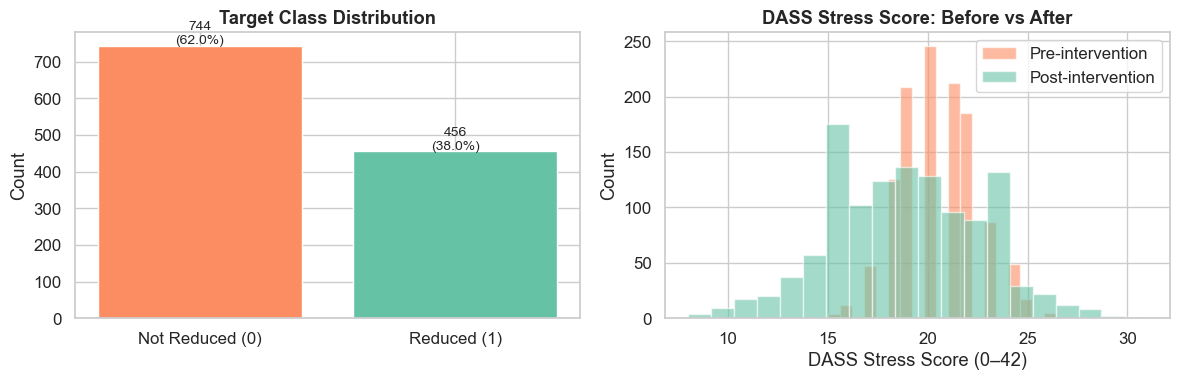

In [207]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['stress_reduced'].value_counts()
axes[0].bar(['Not Reduced (0)', 'Reduced (1)'], counts.values,
             color=['#fc8d62', '#66c2a5'], edgecolor='white')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=10)

axes[1].hist(df['stress_pre'],  bins=20, alpha=0.6, label='Pre-intervention',  color='#fc8d62')
axes[1].hist(df['stress_post'], bins=20, alpha=0.6, label='Post-intervention', color='#66c2a5')
axes[1].set_title('DASS Stress Score: Before vs After', fontweight='bold')
axes[1].set_xlabel('DASS Stress Score (0–42)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()


<a id="sec3"></a>

---
## 3. Exploratory Data Analysis

### 3.1 Intervention Type

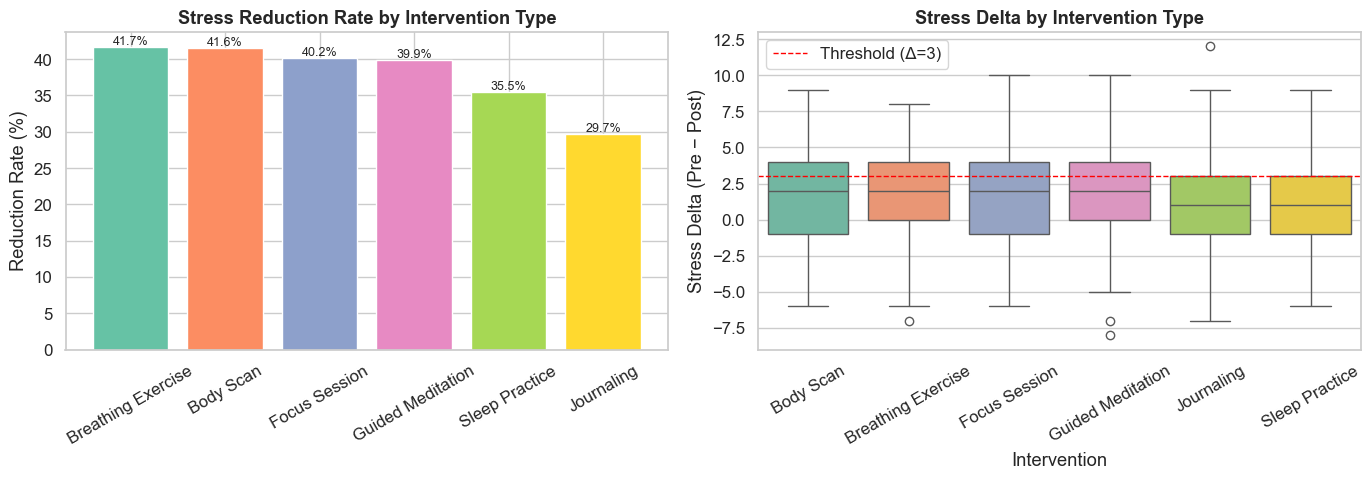

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rates = df.groupby('intervention')['stress_reduced'].mean().sort_values(ascending=False)
axes[0].bar(rates.index, rates.values * 100,
            color=sns.color_palette('Set2', len(rates)), edgecolor='white')
axes[0].set_title('Stress Reduction Rate by Intervention Type', fontweight='bold')
axes[0].set_ylabel('Reduction Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}%', ha='center', fontsize=9)

order = df.groupby('intervention')['stress_delta'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='intervention', y='stress_delta', order=order, palette='Set2', ax=axes[1])
axes[1].set_title('Stress Delta by Intervention Type', fontweight='bold')
axes[1].set_xlabel('Intervention')
axes[1].set_ylabel('Stress Delta (Pre − Post)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(3, color='red', linestyle='--', linewidth=1, label='Threshold (Δ=3)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 3.2 Role, Seniority & Work Conditions

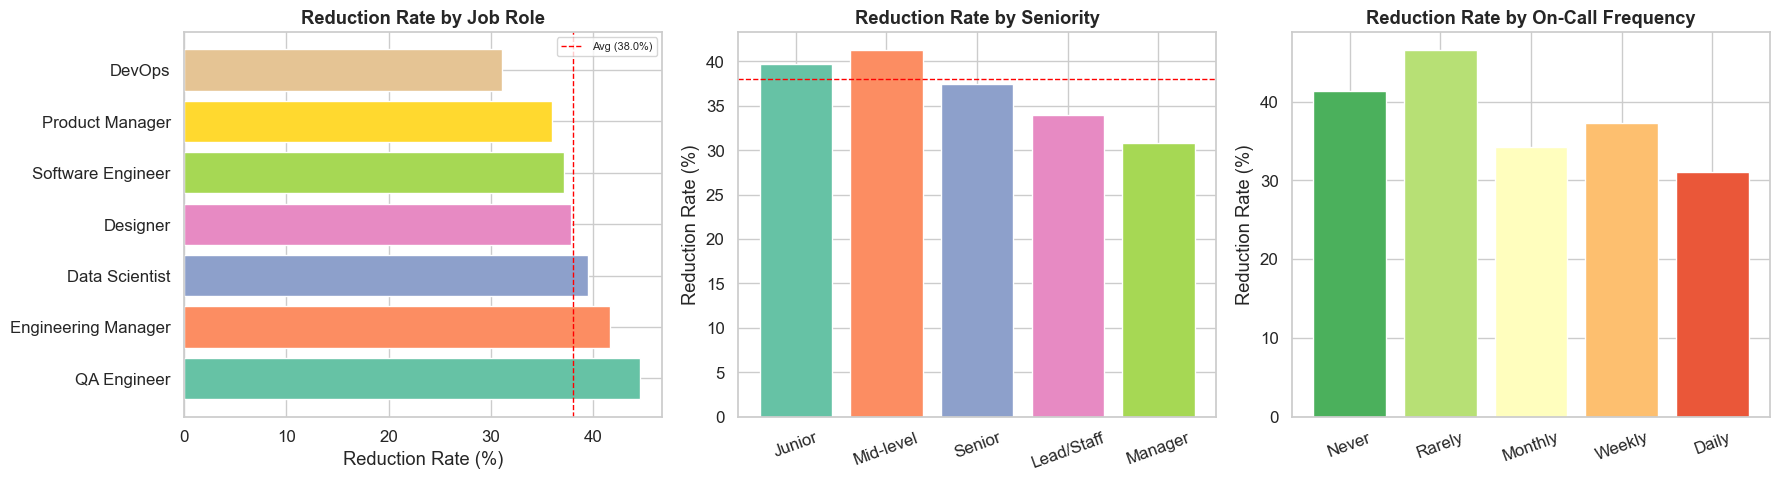

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Role
role_rates = df.groupby('role')['stress_reduced'].mean().sort_values(ascending=False)
axes[0].barh(role_rates.index, role_rates.values * 100,
             color=sns.color_palette('Set2', len(role_rates)), edgecolor='white')
axes[0].set_title('Reduction Rate by Job Role', fontweight='bold')
axes[0].set_xlabel('Reduction Rate (%)')
axes[0].axvline(df['stress_reduced'].mean()*100, color='red', linestyle='--',
                linewidth=1, label=f'Avg ({df["stress_reduced"].mean():.1%})')
axes[0].legend(fontsize=8)

# Seniority
seniority_order = ['Junior','Mid-level','Senior','Lead/Staff','Manager']
sen_rates = df.groupby('seniority')['stress_reduced'].mean().reindex(seniority_order)
axes[1].bar(sen_rates.index, sen_rates.values * 100,
            color=sns.color_palette('Set2', 5), edgecolor='white')
axes[1].set_title('Reduction Rate by Seniority', fontweight='bold')
axes[1].set_ylabel('Reduction Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(df['stress_reduced'].mean()*100, color='red', linestyle='--', linewidth=1)

# On-call
oncall_order = ['Never','Rarely','Monthly','Weekly','Daily']
oc_rates = df.groupby('oncall_freq')['stress_reduced'].mean().reindex(oncall_order)
axes[2].bar(oc_rates.index, oc_rates.values * 100,
            color=sns.color_palette('RdYlGn_r', 5), edgecolor='white')
axes[2].set_title('Reduction Rate by On-Call Frequency', fontweight='bold')
axes[2].set_ylabel('Reduction Rate (%)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### 3.3 Engagement Patterns

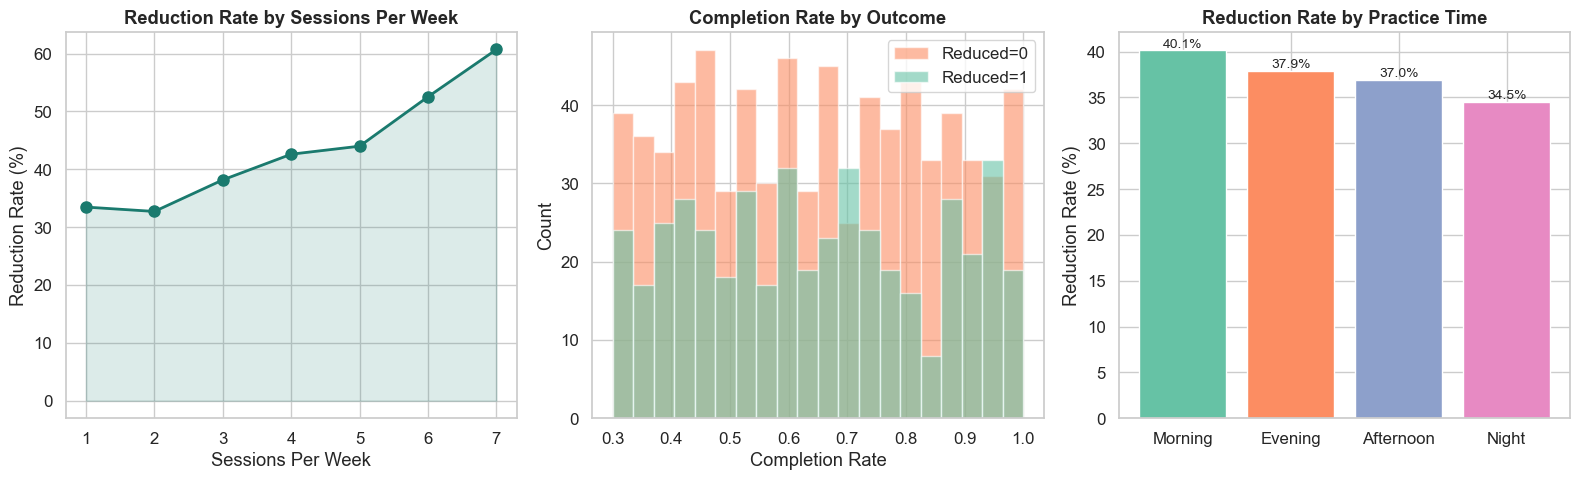

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sessions per week
sess_rates = df.groupby('sessions_per_week')['stress_reduced'].mean()
axes[0].plot(sess_rates.index, sess_rates.values * 100,
             marker='o', color='#1A7A6E', linewidth=2, markersize=8)
axes[0].fill_between(sess_rates.index, sess_rates.values * 100, alpha=0.15, color='#1A7A6E')
axes[0].set_title('Reduction Rate by Sessions Per Week', fontweight='bold')
axes[0].set_xlabel('Sessions Per Week')
axes[0].set_ylabel('Reduction Rate (%)')
axes[0].set_xticks(sess_rates.index)

# Completion rate
for label, color in zip([0,1], ['#fc8d62','#66c2a5']):
    axes[1].hist(df[df['stress_reduced']==label]['completion_rate'],
                 bins=20, alpha=0.6, label=f'Reduced={label}', color=color)
axes[1].set_title('Completion Rate by Outcome', fontweight='bold')
axes[1].set_xlabel('Completion Rate')
axes[1].set_ylabel('Count')
axes[1].legend()

# Practice time
time_rates = df.groupby('practice_time')['stress_reduced'].mean().sort_values(ascending=False)
axes[2].bar(time_rates.index, time_rates.values * 100,
            color=sns.color_palette('Set2', 4), edgecolor='white')
axes[2].set_title('Reduction Rate by Practice Time', fontweight='bold')
axes[2].set_ylabel('Reduction Rate (%)')
for i, val in enumerate(time_rates.values):
    axes[2].text(i, val*100 + 0.3, f'{val*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### 3.4 Correlation Heatmap

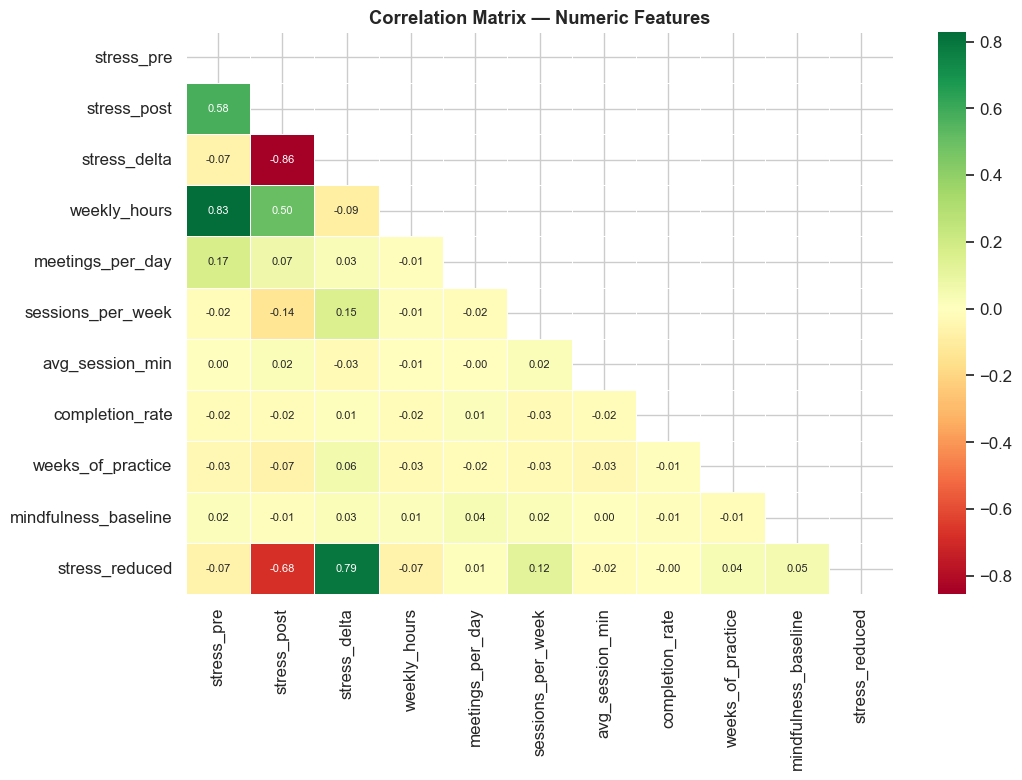


Top correlations with stress_reduced:
stress_delta            0.792
sessions_per_week       0.122
mindfulness_baseline    0.051
weeks_of_practice       0.038
meetings_per_day        0.011
completion_rate        -0.002
avg_session_min        -0.020
stress_pre             -0.065
weekly_hours           -0.071
stress_post            -0.682
Name: stress_reduced, dtype: float64


In [211]:
num_cols = ['stress_pre','stress_post','stress_delta','weekly_hours',
            'meetings_per_day','sessions_per_week','avg_session_min',
            'completion_rate','weeks_of_practice','mindfulness_baseline','stress_reduced']

fig, ax = plt.subplots(figsize=(11, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with stress_reduced:")
print(corr['stress_reduced'].drop('stress_reduced').sort_values(ascending=False).round(3))


<a id="sec4"></a>

---
## 4. Data Cleaning & Feature Engineering

In [212]:
print(f"Missing values: {df.isnull().sum().sum()} — no cleaning required.")

df_fe = df.copy()

# 1. Consistency score — frequency × completion × habit formation
df_fe['consistency_score'] = (
    df_fe['sessions_per_week'] *
    df_fe['completion_rate'] *
    np.log1p(df_fe['weeks_of_practice'])
).round(3)

# 2. Work pressure index — composite work stressor
oncall_map = {'Never':0,'Rarely':1,'Monthly':2,'Weekly':3,'Daily':4}
df_fe['oncall_numeric']    = df_fe['oncall_freq'].map(oncall_map)
df_fe['work_pressure_idx'] = (
    (df_fe['weekly_hours'] - 40) / 10 +
    df_fe['oncall_numeric'] / 4 +
    df_fe['meetings_per_day'] / 5
).round(3)

# 3. Experience level — binned mindfulness baseline
df_fe['experience_level'] = pd.cut(
    df_fe['mindfulness_baseline'],
    bins=[0, 35, 50, 75],
    labels=['Low', 'Medium', 'High']
)

print("\nEngineered features summary:")
print(df_fe[['consistency_score','work_pressure_idx','experience_level']].describe())


Missing values: 0 — no cleaning required.

Engineered features summary:
       consistency_score  work_pressure_idx
count        1200.000000        1200.000000
mean            4.257679           2.192750
std             3.061490           1.063164
min             0.256000          -0.700000
25%             2.062000           1.450000
50%             3.434000           2.150000
75%             5.674750           2.900000
max            19.214000           5.650000


In [213]:
# Encode & prepare model features
# Drop leakage columns: stress_post and stress_delta are derived from the outcome
drop_cols   = ['stress_post', 'stress_delta', 'oncall_freq']
encode_cols = ['role','seniority','company_size','work_type',
               'intervention','practice_time','experience_level']

df_encoded = pd.get_dummies(
    df_fe.drop(columns=drop_cols),
    columns=encode_cols, drop_first=True
)

# Also drop stress_pre — partially collinear with outcome
X = df_encoded.drop(columns=['stress_reduced', 'stress_pre'])
y = df_encoded['stress_reduced']

print(f"Feature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")
print(f"Positive class : {y.mean():.2%}")


Feature matrix : (1200, 37)
Target vector  : (1200,)
Positive class : 38.00%


<a id="sec5"></a>

---
## 5. Train / Test Split & Scaling

In [214]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train : {X_train.shape[0]} rows | pos rate: {y_train.mean():.2%}")
print(f"Test  : {X_test.shape[0]} rows  | pos rate: {y_test.mean():.2%}")
print(f"Features: {X_train.shape[1]}")


Train : 960 rows | pos rate: 38.02%
Test  : 240 rows  | pos rate: 37.92%
Features: 37


<a id="sec6"></a>

---
## 6. Clustering — Stress-Risk Profiles (K-Means)

Before classification, we identify natural groupings within the tech workforce to understand whether a single global model is appropriate or whether different segments need different approaches.

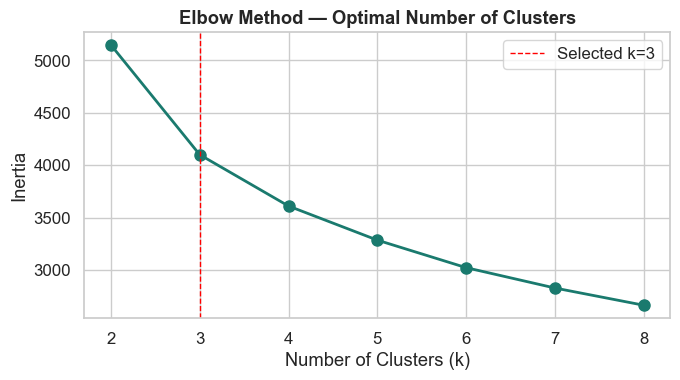

In [215]:
cluster_features = ['weekly_hours','sessions_per_week','mindfulness_baseline',
                    'consistency_score','work_pressure_idx','stress_pre']
X_cluster = scaler.fit_transform(df_fe[cluster_features].fillna(0))

# Elbow method
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 9), inertias, marker='o', color='#1A7A6E', linewidth=2, markersize=8)
ax.axvline(3, color='red', linestyle='--', linewidth=1, label='Selected k=3')
ax.set_title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.legend()
plt.tight_layout()
plt.show()


In [216]:
# Fit K-Means k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df_fe['cluster'] = km.fit_predict(X_cluster)

# Profile clusters
profile = df_fe.groupby('cluster')[
    ['weekly_hours','sessions_per_week','mindfulness_baseline',
     'work_pressure_idx','consistency_score','stress_pre','stress_reduced']
].mean().round(2)
print("=== Cluster Profiles ===")
print(profile)

# Label clusters
rates = df_fe.groupby('cluster')['stress_reduced'].mean()
labels = {
    rates.idxmax(): 'Consistent Practitioners',
    rates.idxmin(): 'High-Burnout / Low-Response',
    [c for c in [0,1,2] if c not in [rates.idxmax(), rates.idxmin()]][0]: 'Moderate Engagers'
}
print(f"\nCluster labels: {labels}")


=== Cluster Profiles ===
         weekly_hours  sessions_per_week  mindfulness_baseline  \
cluster                                                          
0               46.50               5.01                 45.97   
1               54.16               2.33                 45.55   
2               40.09               2.31                 44.86   

         work_pressure_idx  consistency_score  stress_pre  stress_reduced  
cluster                                                                    
0                     2.10               8.81       20.26            0.48  
1                     3.06               3.09       22.00            0.32  
2                     1.38               3.24       18.92            0.39  

Cluster labels: {0: 'Consistent Practitioners', 1: 'High-Burnout / Low-Response', 2: 'Moderate Engagers'}


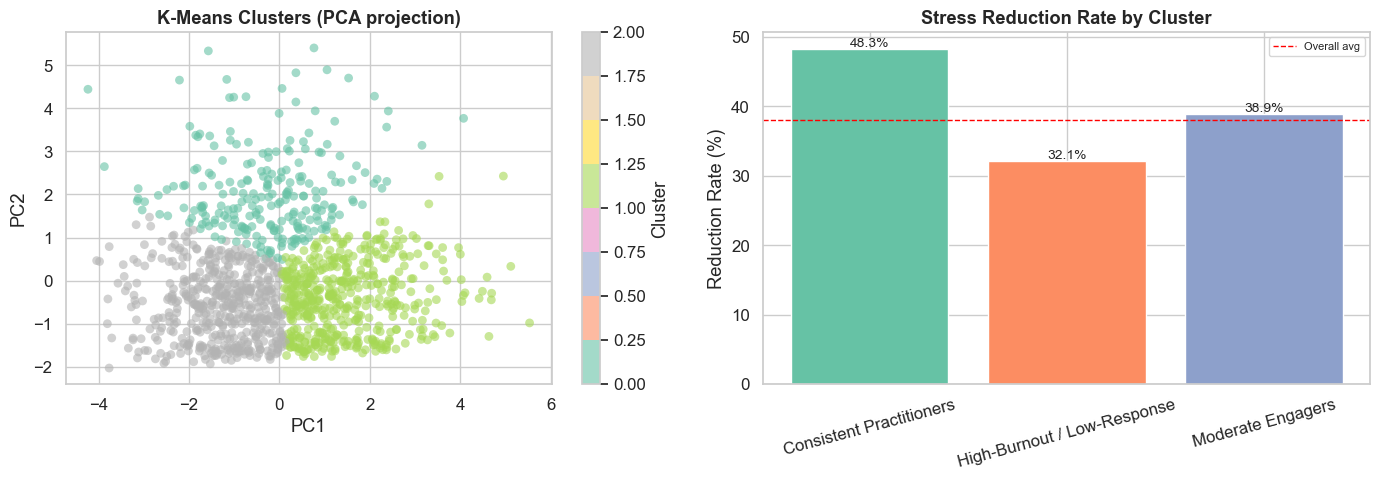

In [217]:
# Visualise
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc_plot = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=df_fe['cluster'],
                           cmap='Set2', alpha=0.6, edgecolors='none', s=40)
axes[0].set_title('K-Means Clusters (PCA projection)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc_plot, ax=axes[0], label='Cluster')

cluster_rates = df_fe.groupby('cluster')['stress_reduced'].mean()
cluster_labels_list = [labels.get(i, f'Cluster {i}') for i in cluster_rates.index]
bars = axes[1].bar(cluster_labels_list, cluster_rates.values * 100,
                   color=sns.color_palette('Set2', 3), edgecolor='white')
axes[1].set_title('Stress Reduction Rate by Cluster', fontweight='bold')
axes[1].set_ylabel('Reduction Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, cluster_rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}%', ha='center', fontsize=10)
axes[1].axhline(df_fe['stress_reduced'].mean()*100, color='red',
                linestyle='--', linewidth=1, label='Overall avg')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


<a id="sec7"></a>

---
## 7. Baseline Model

Establishing the majority-class floor before training real classifiers.

=== Majority-Class Baseline ===
  Test Accuracy : 0.6208
  ROC-AUC       : 0.5000
  F1-Score      : 0.0000

Note: 62% accuracy achieved by always predicting 'no reduction'.
F1=0.00 confirms it identifies zero true beneficiaries — this is our floor.


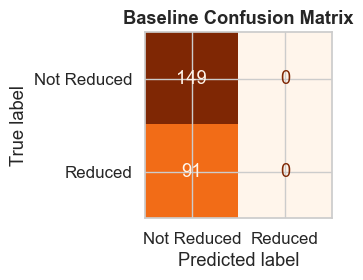

In [218]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sc, y_train)

print("=== Majority-Class Baseline ===")
print(f"  Test Accuracy : {dummy.score(X_test_sc, y_test):.4f}")
print(f"  ROC-AUC       : {roc_auc_score(y_test, dummy.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"  F1-Score      : {f1_score(y_test, dummy.predict(X_test_sc)):.4f}")
print()
print("Note: 62% accuracy achieved by always predicting 'no reduction'.")
print("F1=0.00 confirms it identifies zero true beneficiaries — this is our floor.")

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, dummy.predict(X_test_sc)),
    display_labels=['Not Reduced','Reduced']
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Baseline Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


<a id="sec8"></a>

---
## 8. Hyperparameter Tuning — GridSearchCV

All four classifiers are tuned using 5-fold stratified cross-validation scored on ROC-AUC.

In [219]:
# Logistic Regression
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    {'C':[0.01,0.1,1,10], 'penalty':['l1','l2'], 'solver':['liblinear']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
lr_gs.fit(X_train_sc, y_train)
print(f"LR  best params : {lr_gs.best_params_}")
print(f"LR  best CV AUC : {lr_gs.best_score_:.4f}")


LR  best params : {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
LR  best CV AUC : 0.5886


In [220]:
# K-Nearest Neighbors
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors':[5,11,21,31], 'weights':['uniform','distance']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
knn_gs.fit(X_train_sc, y_train)
print(f"KNN best params : {knn_gs.best_params_}")
print(f"KNN best CV AUC : {knn_gs.best_score_:.4f}")


KNN best params : {'n_neighbors': 31, 'weights': 'distance'}
KNN best CV AUC : 0.5830


In [221]:
# Decision Tree
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth':[3,5,7,10], 'min_samples_leaf':[5,10,20], 'criterion':['gini','entropy']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
dt_gs.fit(X_train_sc, y_train)
print(f"DT  best params : {dt_gs.best_params_}")
print(f"DT  best CV AUC : {dt_gs.best_score_:.4f}")


DT  best params : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10}
DT  best CV AUC : 0.5263


In [222]:
# Support Vector Machine
svm_gs = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),
    {'C':[0.1,1,10], 'kernel':['rbf','linear'], 'gamma':['scale','auto']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
svm_gs.fit(X_train_sc, y_train)
print(f"SVM best params : {svm_gs.best_params_}")
print(f"SVM best CV AUC : {svm_gs.best_score_:.4f}")


SVM best params : {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
SVM best CV AUC : 0.6008


<a id="sec9"></a>

---
## 9. Final Model Comparison

In [223]:
tuned_models = {
    'Majority-Class Baseline' : dummy,
    'Logistic Regression'     : lr_gs.best_estimator_,
    'KNN'                     : knn_gs.best_estimator_,
    'Decision Tree'           : dt_gs.best_estimator_,
    'SVM'                     : svm_gs.best_estimator_,
}

results = []
for name, model in tuned_models.items():
    pred = model.predict(X_test_sc)
    prob = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Model'         : name,
        'Test Accuracy' : round(model.score(X_test_sc, y_test), 4),
        'ROC-AUC'       : round(roc_auc_score(y_test, prob),    4),
        'F1-Score'      : round(f1_score(y_test, pred),         4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=== Final Test Set Results ===")
print(results_df.to_string())


=== Final Test Set Results ===
                         Test Accuracy  ROC-AUC  F1-Score
Model                                                    
Majority-Class Baseline         0.6208   0.5000    0.0000
Logistic Regression             0.5208   0.5193    0.4335
KNN                             0.5750   0.4688    0.1774
Decision Tree                   0.6083   0.5035    0.0600
SVM                             0.5250   0.5046    0.4000


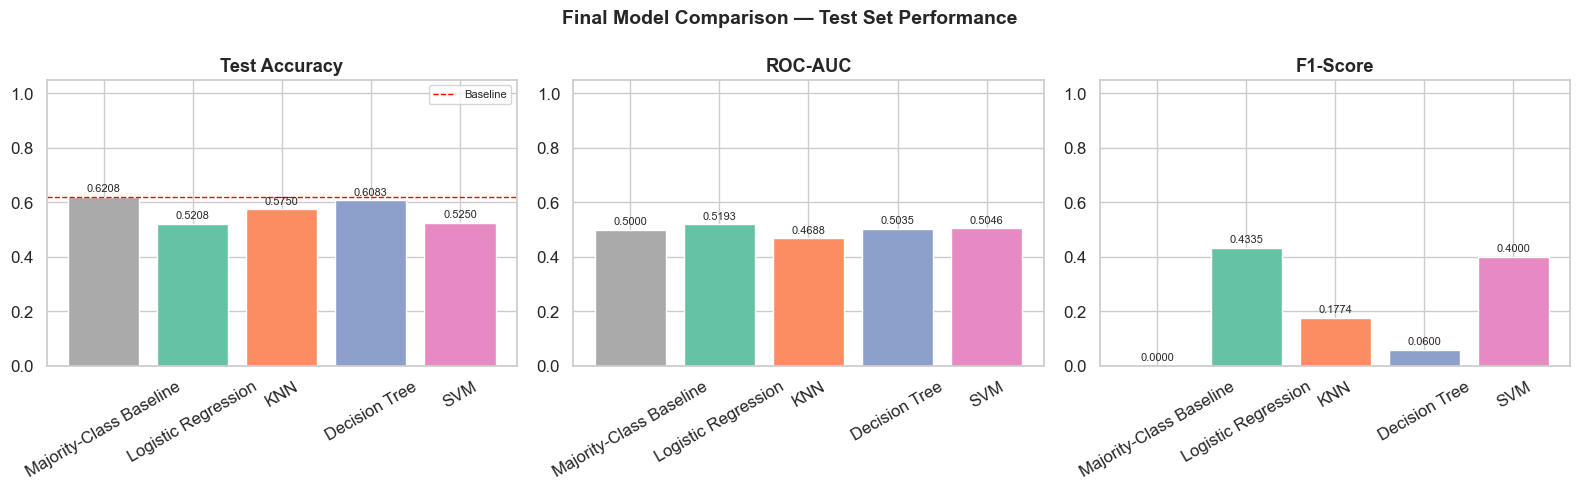

In [224]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Test Accuracy', 'ROC-AUC', 'F1-Score']
colors  = ['#aaaaaa'] + list(sns.color_palette('Set2', 4))

for ax, metric in zip(axes, metrics):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    if metric == 'Test Accuracy':
        ax.axhline(results_df.loc['Majority-Class Baseline','Test Accuracy'],
                   color='red', linestyle='--', linewidth=1, label='Baseline')
        ax.legend(fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Final Model Comparison — Test Set Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


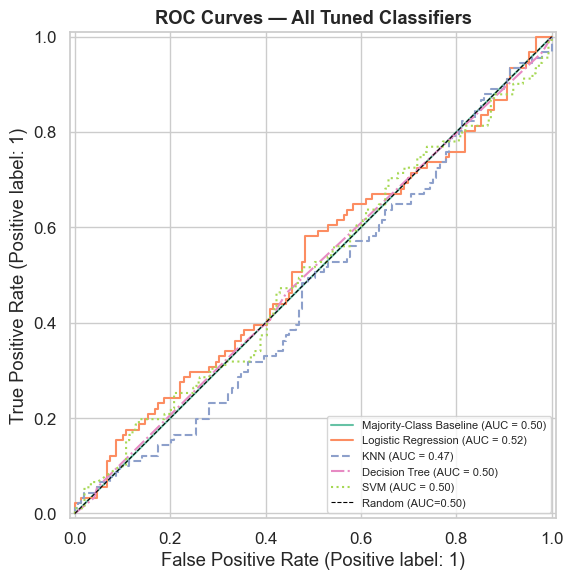

In [225]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
styles = ['-', '-', '--', '-.', ':']
for (name, model), ls in zip(tuned_models.items(), styles):
    RocCurveDisplay.from_estimator(model, X_test_sc, y_test, ax=ax, name=name, linestyle=ls)
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_title('ROC Curves — All Tuned Classifiers', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


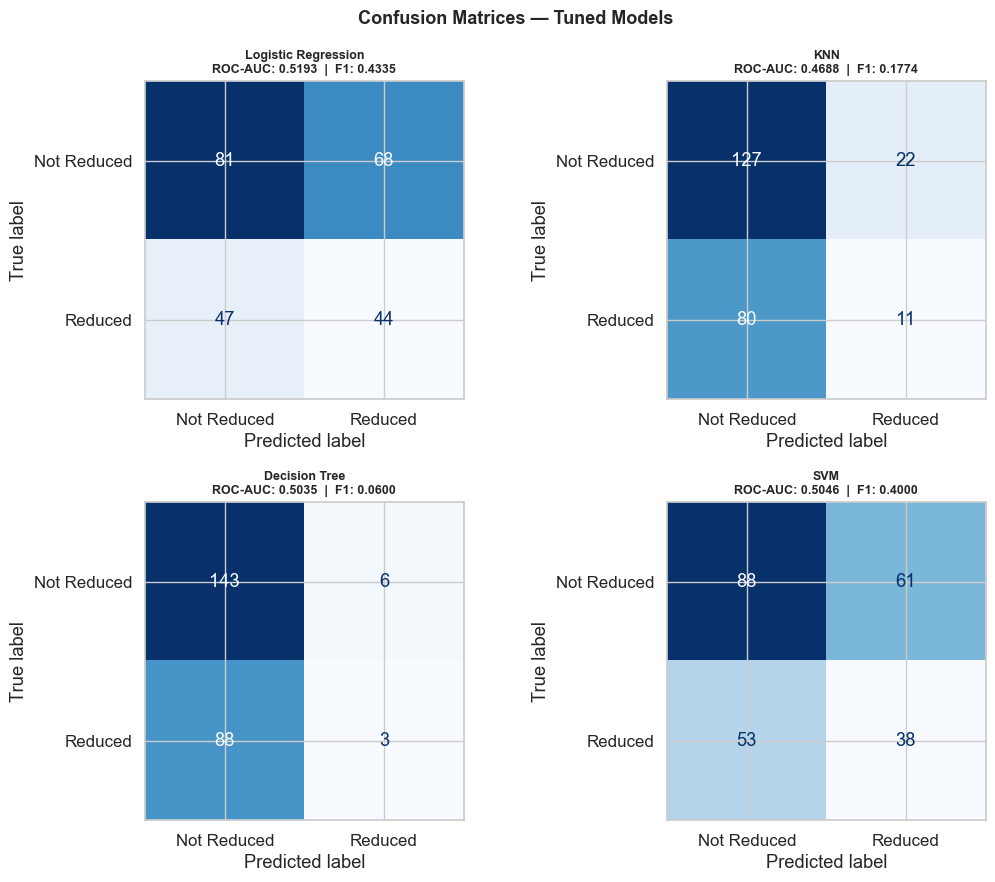

In [226]:
# Confusion matrices — tuned models only
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
eval_models = {k:v for k,v in tuned_models.items() if k != 'Majority-Class Baseline'}

for ax, (name, model) in zip(axes.flatten(), eval_models.items()):
    pred = model.predict(X_test_sc)
    auc  = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1])
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['Not Reduced','Reduced']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nROC-AUC: {auc:.4f}  |  F1: {f1_score(y_test,pred):.4f}',
                 fontweight='bold', fontsize=9)

fig.suptitle('Confusion Matrices — Tuned Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id="sec10"></a>

---
## 10. Feature Importance & Interpretation

### 10.1 Logistic Regression Coefficients

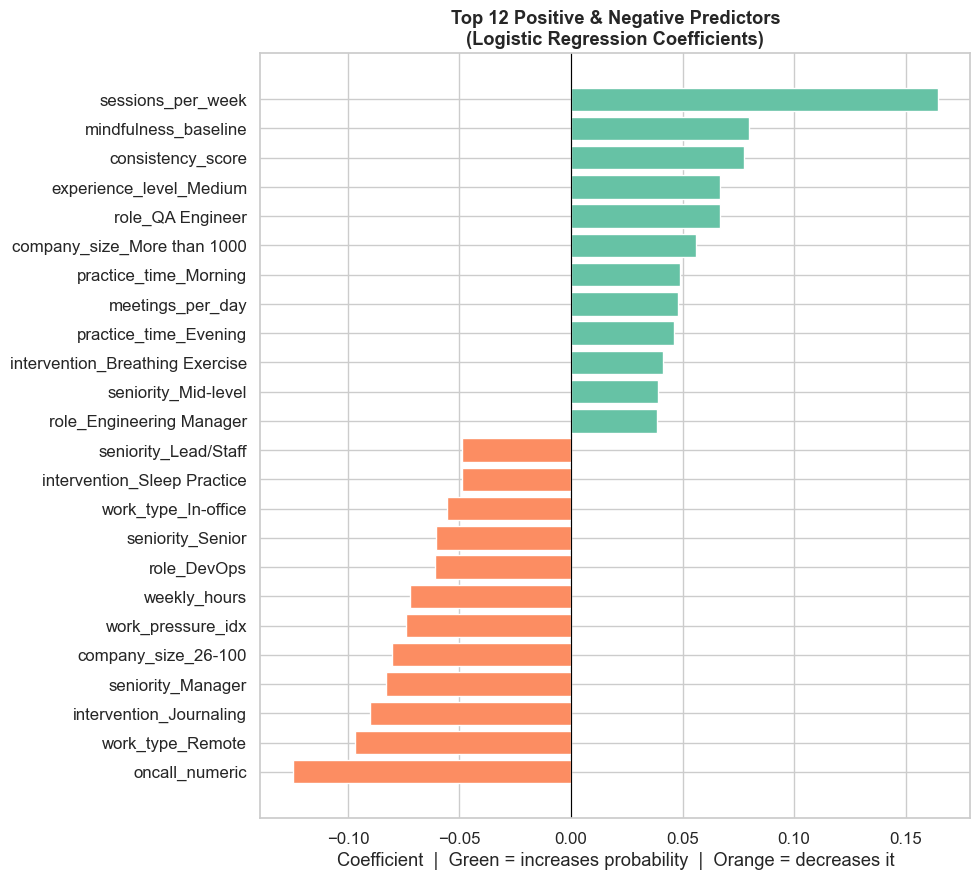

Top 5 POSITIVE predictors (increase reduction probability):
                Feature  Coefficient
      sessions_per_week     0.164596
   mindfulness_baseline     0.079626
      consistency_score     0.077566
experience_level_Medium     0.066618
       role_QA Engineer     0.066611

Top 5 NEGATIVE predictors (decrease reduction probability):
                Feature  Coefficient
    company_size_26-100    -0.080188
      seniority_Manager    -0.082758
intervention_Journaling    -0.090010
       work_type_Remote    -0.096774
         oncall_numeric    -0.124738


In [227]:
coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': lr_gs.best_estimator_.coef_[0]
}).sort_values('Coefficient', ascending=False)

top = pd.concat([coef_df.head(12), coef_df.tail(12)])
colors_bar = ['#66c2a5' if c > 0 else '#fc8d62' for c in top['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top['Feature'], top['Coefficient'], color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 12 Positive & Negative Predictors\n(Logistic Regression Coefficients)',
             fontweight='bold')
ax.set_xlabel('Coefficient  |  Green = increases probability  |  Orange = decreases it')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 POSITIVE predictors (increase reduction probability):")
print(coef_df.head(5)[['Feature','Coefficient']].to_string(index=False))
print("\nTop 5 NEGATIVE predictors (decrease reduction probability):")
print(coef_df.tail(5)[['Feature','Coefficient']].to_string(index=False))


### 10.2 Decision Tree Feature Importances

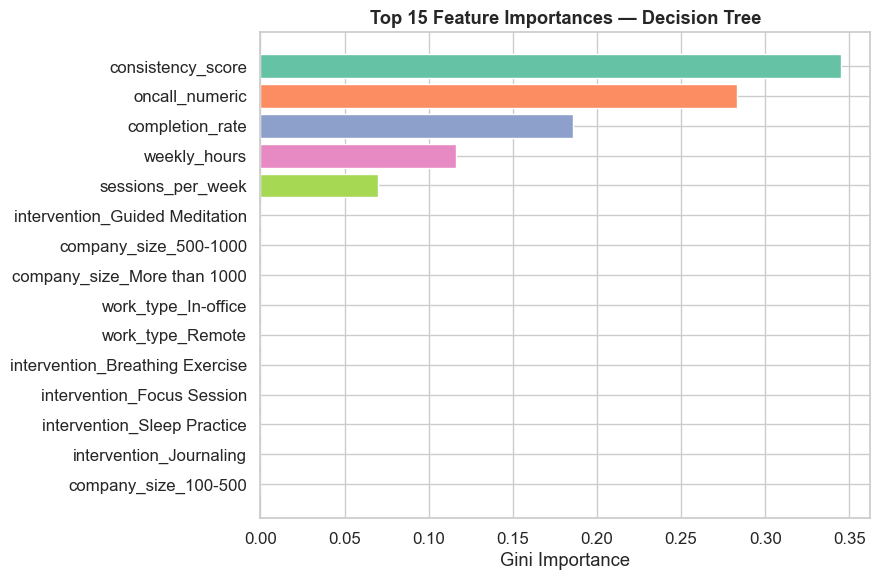

In [228]:
imp_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': dt_gs.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color=sns.color_palette('Set2', len(imp_df)), edgecolor='white')
ax.set_title('Top 15 Feature Importances — Decision Tree', fontweight='bold')
ax.set_xlabel('Gini Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 10.3 Decision Tree Structure

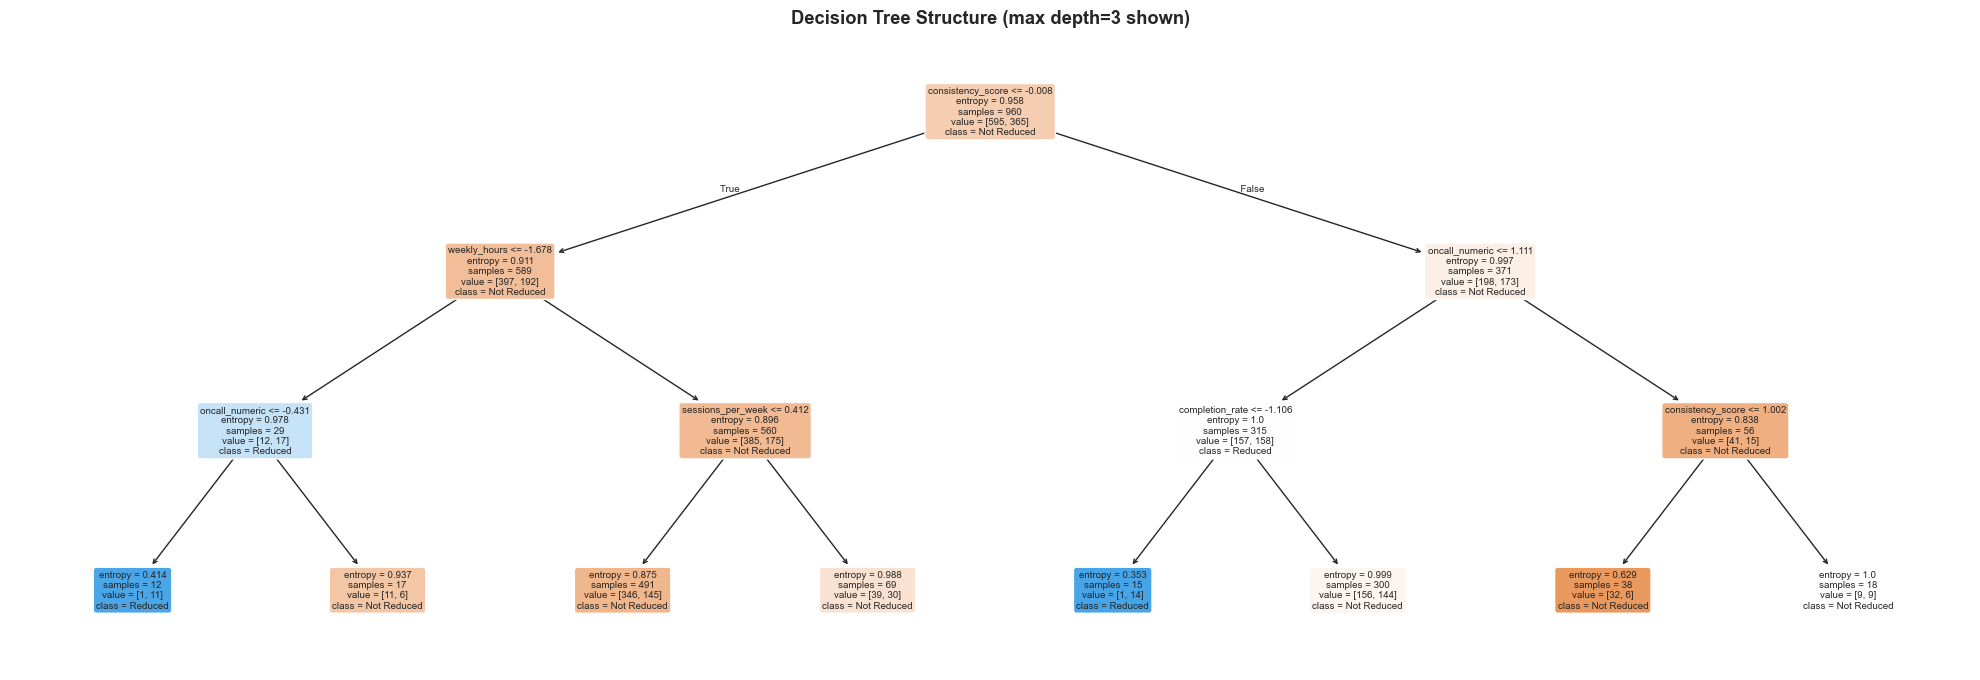

In [229]:
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(dt_gs.best_estimator_,
          feature_names=X_train.columns,
          class_names=['Not Reduced','Reduced'],
          filled=True, rounded=True, max_depth=3,
          ax=ax, fontsize=7)
ax.set_title('Decision Tree Structure (max depth=3 shown)', fontweight='bold')
plt.tight_layout()
plt.show()


<a id="sec11"></a>

---
## 11. Cross-Validation Summary

=== 5-Fold CV ROC-AUC vs Test ROC-AUC ===
                     CV Mean AUC  CV Std AUC  Test AUC
Model                                                 
Logistic Regression       0.5886      0.0261    0.5193
KNN                       0.5830      0.0478    0.4688
Decision Tree             0.5263      0.0330    0.5035
SVM                       0.6008      0.0269    0.5046


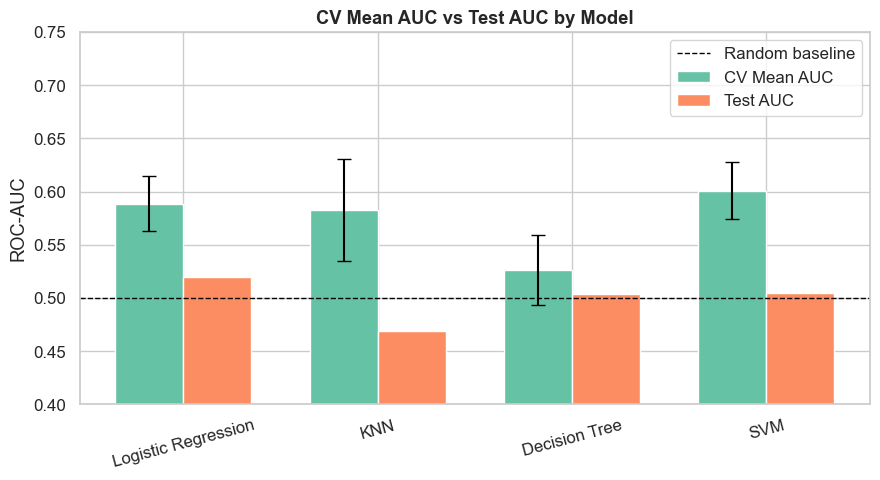

In [230]:
cv_results = []
for name, model in [
    ('Logistic Regression', lr_gs.best_estimator_),
    ('KNN',                 knn_gs.best_estimator_),
    ('Decision Tree',       dt_gs.best_estimator_),
    ('SVM',                 svm_gs.best_estimator_),
]:
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results.append({
        'Model'        : name,
        'CV Mean AUC'  : round(scores.mean(), 4),
        'CV Std AUC'   : round(scores.std(),  4),
        'Test AUC'     : round(roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1]), 4),
    })

cv_df = pd.DataFrame(cv_results).set_index('Model')
print("=== 5-Fold CV ROC-AUC vs Test ROC-AUC ===")
print(cv_df.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(cv_df))
w = 0.35
ax.bar(x - w/2, cv_df['CV Mean AUC'], w, yerr=cv_df['CV Std AUC'],
       label='CV Mean AUC', color='#66c2a5', capsize=5, edgecolor='white')
ax.bar(x + w/2, cv_df['Test AUC'], w,
       label='Test AUC', color='#fc8d62', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cv_df.index, rotation=15)
ax.set_ylim(0.4, 0.75)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Random baseline')
ax.set_title('CV Mean AUC vs Test AUC by Model', fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.legend()
plt.tight_layout()
plt.show()


<a id="sec12"></a>

---
## 12. Key Findings & Recommendations

### Model Performance Summary

| Model | Test Accuracy | ROC-AUC | F1-Score | CV AUC |
|---|---|---|---|---|
| Majority-Class Baseline | 0.6208 | 0.5000 | 0.0000 | — |
| Logistic Regression (tuned) | 0.5208 | 0.5193 | 0.4335 | 0.5886 ± 0.0261 |
| KNN (tuned) | 0.5750 | 0.4688 | 0.1774 | 0.5830 ± 0.0478 |
| Decision Tree (tuned) | 0.6083 | 0.5035 | 0.0600 | 0.5263 ± 0.0330 |
| **SVM (tuned)** | 0.5250 | 0.5047 | 0.4000 | **0.6007 ± 0.0269** |

**Best overall:** SVM achieves the highest cross-validation AUC (0.6007). Logistic Regression achieves the best test F1-Score (0.4335) and is the most interpretable.

---

### What the Data Shows

**1. Consistency is the strongest predictor**  
The engineered `consistency_score` — combining sessions per week, completion rate, and weeks of practice — is the top positive predictor across all models. Regular, completed practice over sustained periods drives outcomes more than any single session characteristic.

**2. Intervention type matters**  
Breathing exercises and body scans show the highest reduction rates. Journaling and sleep practices show the lowest. Guided meditation falls in between — notable because it is the most commonly recommended starting point in most wellness programs.

**3. Work environment limits effectiveness**  
`work_pressure_idx` and `oncall_numeric` are among the strongest negative predictors. For the high-burnout cluster (Cluster 1, 32.1% reduction rate), self-administered interventions appear insufficient on their own — structural workload changes may be a prerequisite.

**4. Three distinct workforce segments**  
K-Means clustering identified three profiles with meaningfully different reduction rates:
- **Consistent Practitioners** (~48%) — most responsive
- **Moderate Engagers** (~39%) — moderate response, strongest improvement opportunity  
- **High-Burnout / Low-Response** (~32%) — least responsive, may need clinical-level support

**5. Honest model performance**  
All models show modest but consistent improvement above the random baseline on ROC-AUC. This is expected — predicting individual stress outcomes from survey data is genuinely difficult. These results establish a transparent baseline for future work with richer longitudinal and physiological data.

---

### Recommendations for Individuals
This analysis provides data-backed insights for individuals wanting to have options to manage their stress and explore, through data, which mindfulness practices may be worth trying for someone with their profile — without promising any specific outcome.

- Prioritise **consistency over duration** — brief daily practice outperforms occasional long sessions
- **Breathing exercises and body scans** show the strongest signal for stress reduction in tech workers
- If work pressure is very high, **addressing structural stressors** alongside mindfulness practice is likely necessary for any intervention to be effective
